# **Import Library**

In [307]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# **Data Loading**

In [308]:
# Definisi nama kolom secara manual karena file aslinya nggak ada header
column_names = [
    'mpg', 'cylinders', 'displacement', 'horsepower', 
    'weight', 'acceleration', 'model_year', 'origin', 'car_name'
]

# Import data
df_train = pd.read_csv(
    'datasets/auto-mpg.data', 
    sep=r'\s+',             # Memisahkan berdasarkan spasi/whitespace yang banyak
    names=column_names,    # Memberikan nama kolom
    na_values='?'          # Mengubah tanda '?' jadi NaN (Not a Number)
)

In [309]:
df_train.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [310]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


In [311]:
df_train.describe(include='all')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864,NaN
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055,NaN
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000,NaN
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000,NaN
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,NaN


# **Data Cleaning**

In [312]:
df_clean = df_train.copy()

## *drop fitur tidak guna, missing values, dan data duplicated*

In [313]:
df_clean = df_clean.drop(columns=['car_name'])

In [314]:
missing_values = df_clean.isnull().sum()
missing_values = missing_values[missing_values > 0]

# Menghitung median dari kolom horsepower
median_hp = df_clean['horsepower'].median()

# Mengisi NaN dengan nilai median tersebut
df_clean['horsepower'] = df_clean['horsepower'].fillna(median_hp)

In [315]:
# Mengidentifikasi baris duplikat
duplicates = df_clean.duplicated()
print(df_clean[duplicates])

Empty DataFrame
Columns: [mpg, cylinders, displacement, horsepower, weight, acceleration, model_year, origin]
Index: []


## *konversi tipe data (one hot encoding)*

In [316]:
df_clean = pd.get_dummies(df_clean, columns=['origin', 'cylinders'])

## *drop outlier*

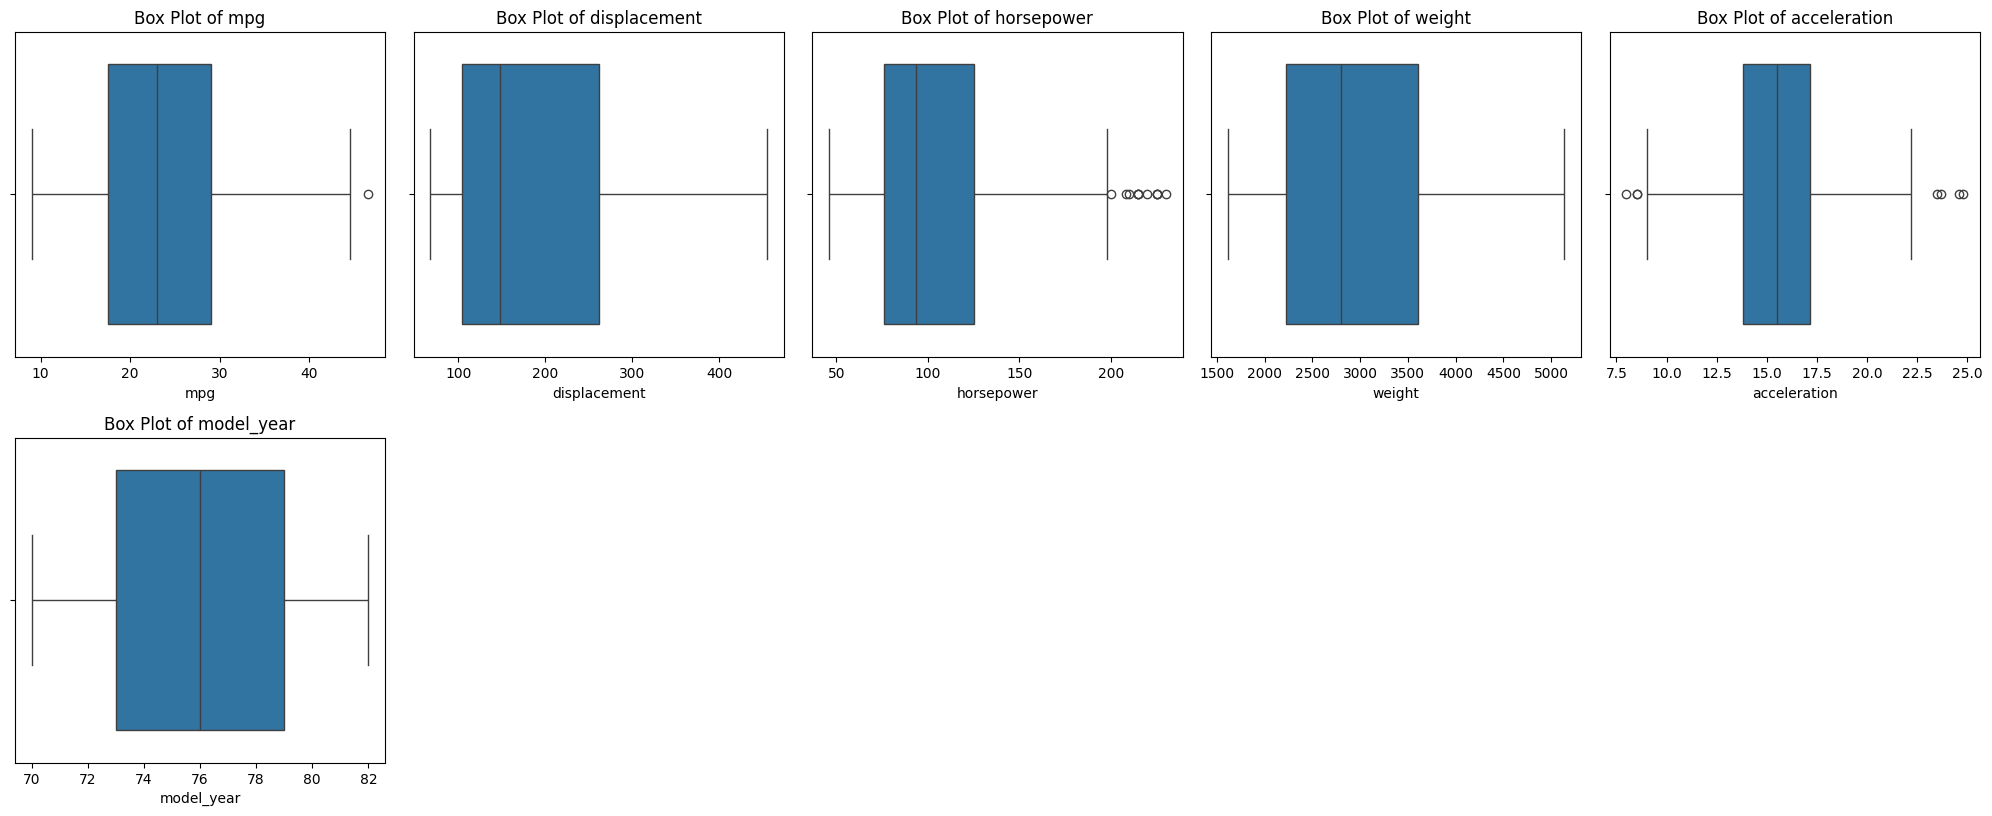

In [317]:
numeric_features = df_clean.select_dtypes(include=np.number).columns

plt.figure(figsize=(20, 20))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(5, 5, i)
    sns.boxplot(x=df_clean[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [318]:
# Hitung IQR per kolom
Q1 = df_clean[numeric_features].quantile(0.25)
Q3 = df_clean[numeric_features].quantile(0.75)
IQR = Q3 - Q1

# Buat mask: baris yang TIDAK outlier
mask = ~((df_clean[numeric_features] < (Q1 - 1.5 * IQR)) | (df_clean[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)

df_clean = df_clean[mask]  # kolom kategorikal ikut otomatis

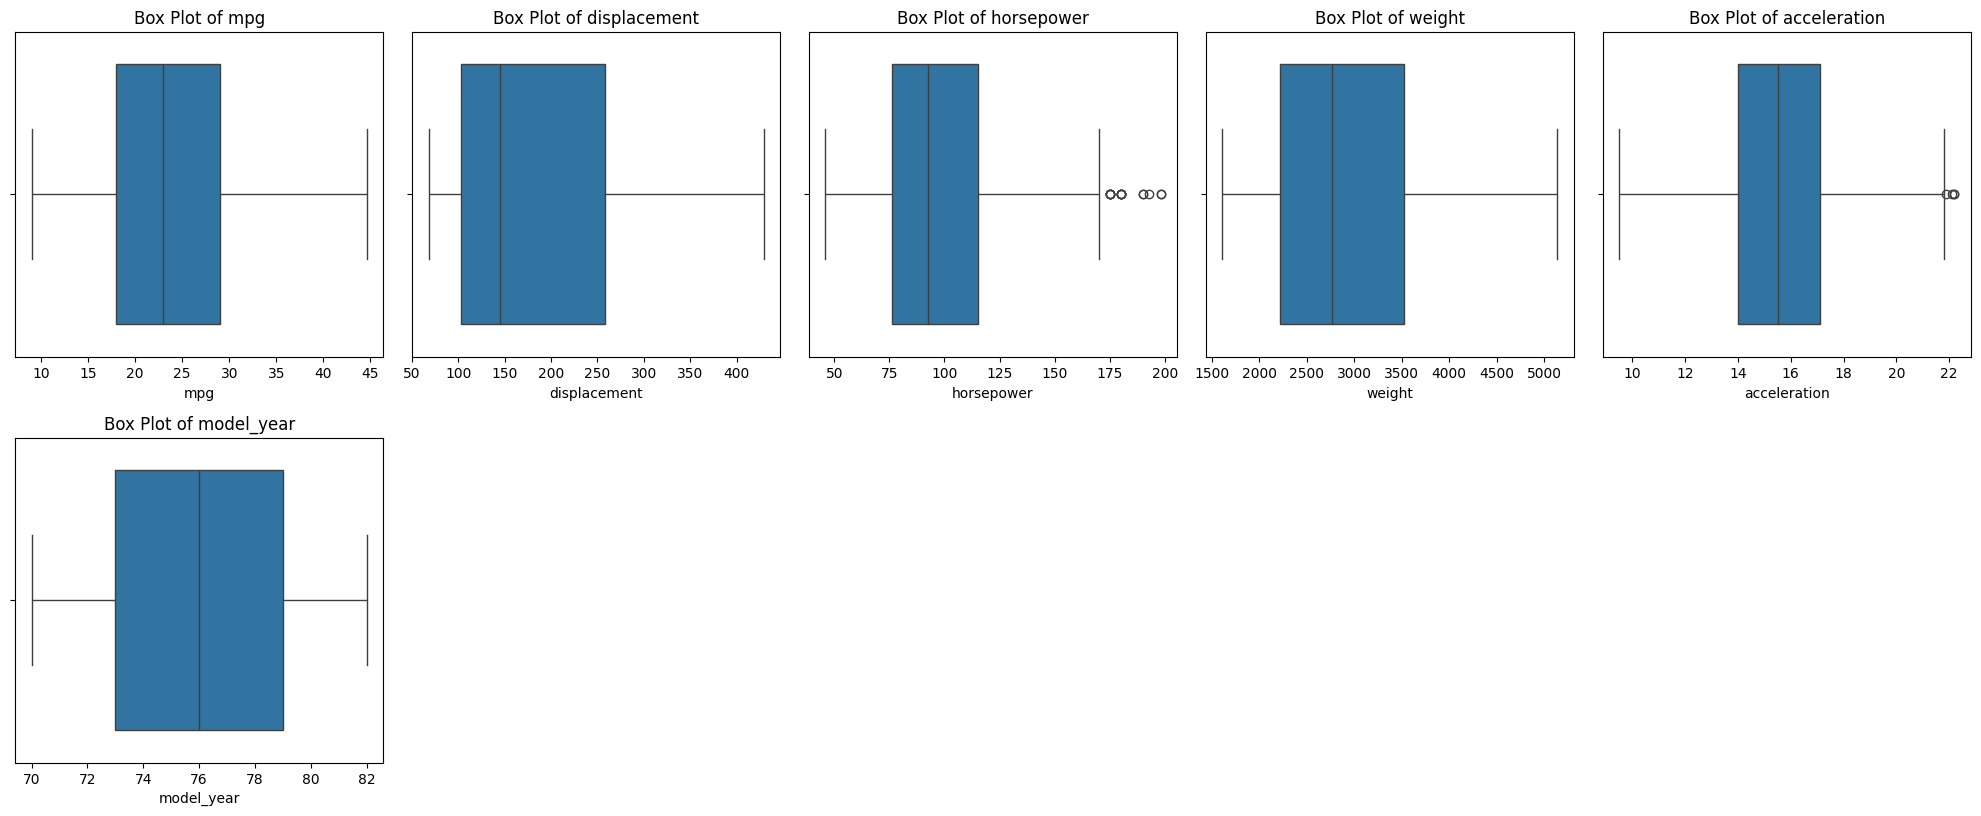

In [319]:
plt.figure(figsize=(20, 20))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(5, 5, i)
    sns.boxplot(x=df_clean[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

# **Exploratory Data Analysis (EDA)**

In [320]:
df_clean.describe(include='all')

,mpg,displacement,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3,cylinders_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380,380,380,380,380,380,380,380
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False,True,False,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,236,314,302,376,199,377,296,290
mean,23.701579,187.446053,101.276316,2933.168421,15.638421,76.152632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7.509740,98.133984,33.060849,822.759728,2.488570,3.617295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,9.000000,68.000000,46.000000,1613.000000,9.500000,70.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,18.000000,103.250000,76.000000,2219.750000,14.000000,73.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,23.000000,144.500000,92.500000,2764.500000,15.500000,76.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,29.000000,258.000000,115.000000,3521.250000,17.125000,79.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## *cek persebaran data*

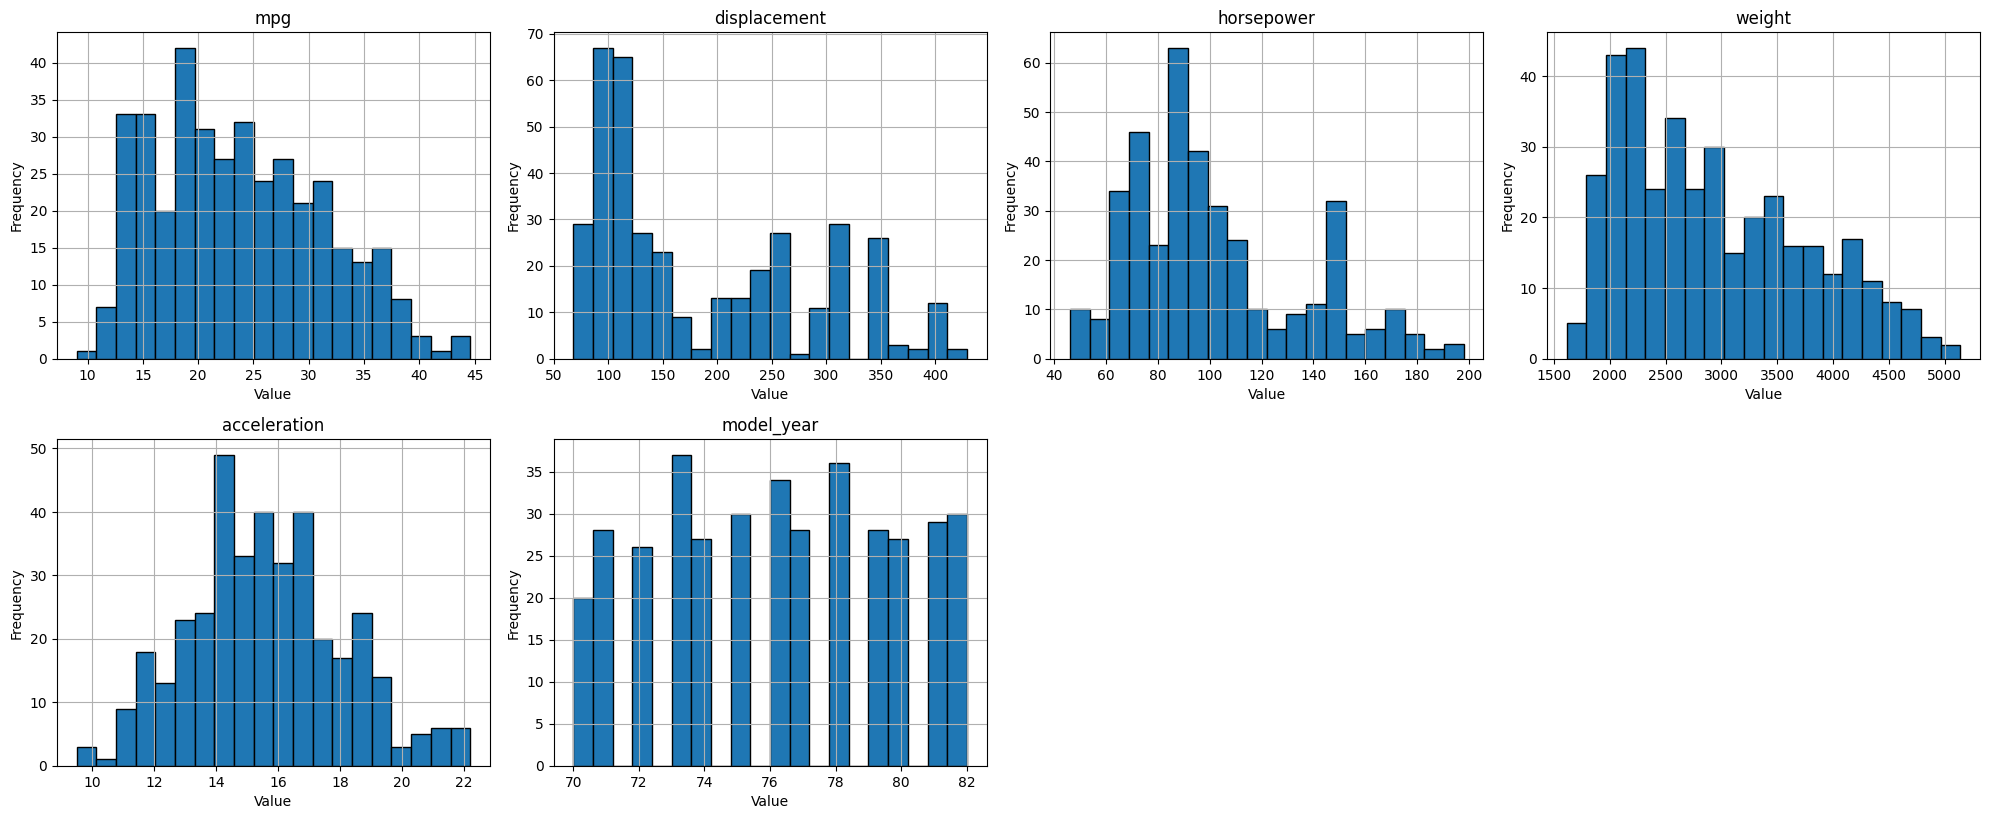

In [321]:
# Menghitung jumlah variabel
num_vars = df_clean.shape[1]
 
# Menentukan jumlah baris dan kolom untuk grid subplot
n_cols = 4  # Jumlah kolom yang diinginkan
n_rows = -(-num_vars // n_cols)  # Ceiling division untuk menentukan jumlah baris
 
# Membuat subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
 
# Flatten axes array untuk memudahkan iterasi jika diperlukan
axes = axes.flatten()
 
# Plot setiap variabel
for i, column in enumerate(numeric_features):
    df_clean[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
 
# Menghapus subplot yang tidak terpakai (jika ada)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
 
# Menyesuaikan layout agar lebih rapi
plt.tight_layout()
plt.show()

## *cek korelasi semua variabel independen terhadap variabel dependen*

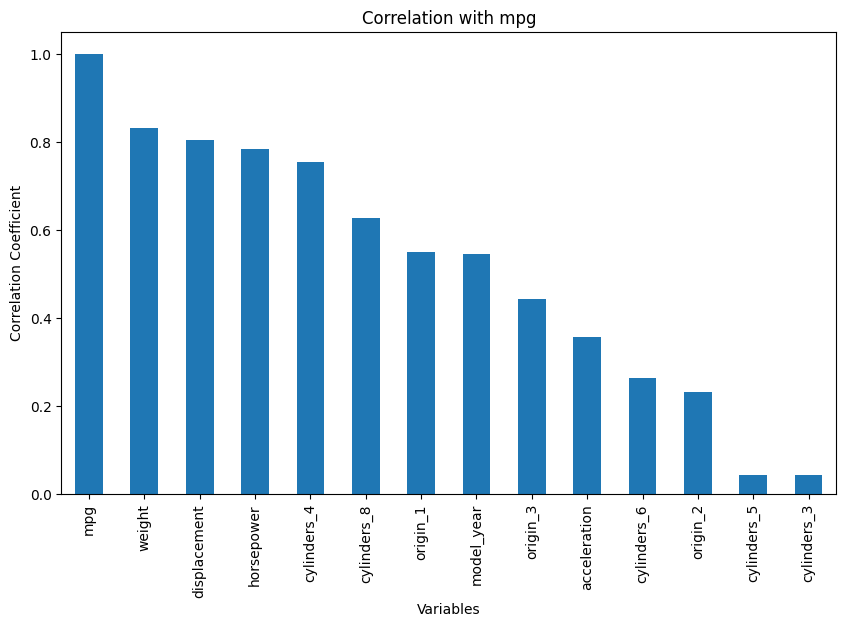

In [322]:
# Menghitung korelasi antara variabel target dan semua variabel lainnya
target_corr = df_clean.corr()['mpg']
 
# (Opsional) Mengurutkan hasil korelasi berdasarkan kekuatan korelasi
target_corr_sorted = target_corr.abs().sort_values(ascending=False)
 
plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with mpg')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

## *cek multikolinearitas (hubungan antarvariabel)*

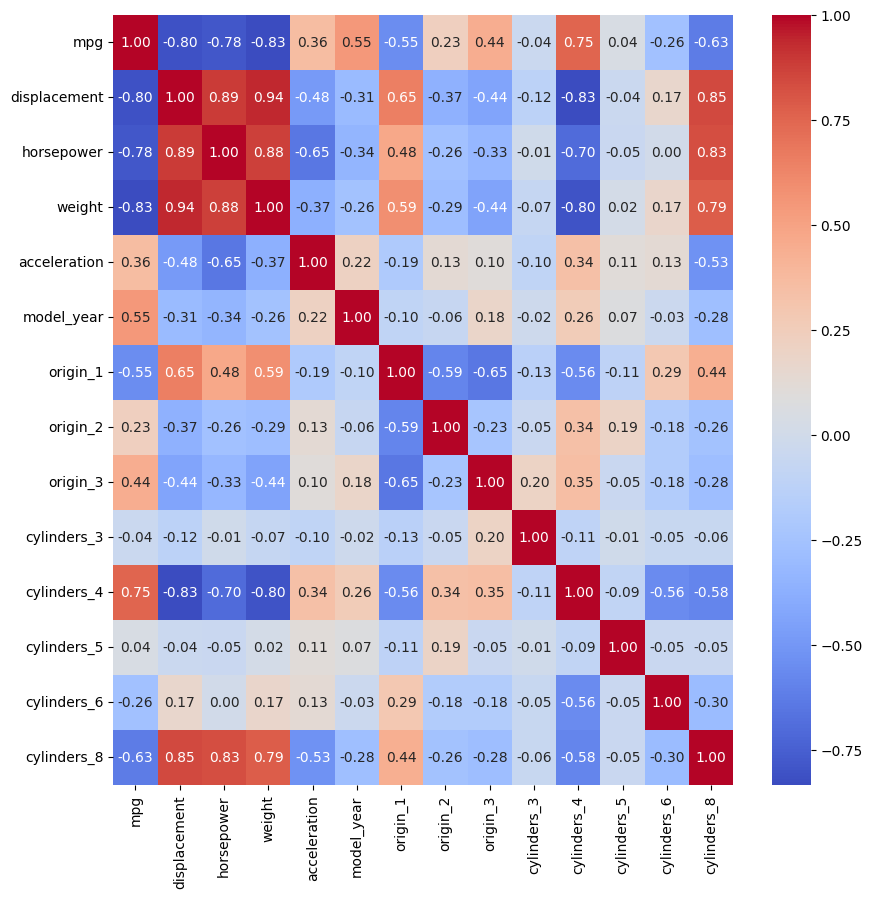

In [323]:
plt.figure(figsize=(10, 10))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

# **Data Splitting**

In [324]:
df_transform = df_clean.copy()

## *transformasi fitur yang skew*

In [325]:
skewed_cols = ['displacement', 'horsepower', 'weight']
df_transform[skewed_cols] = np.log1p(df_transform[skewed_cols])

## *split data*

In [326]:
# Memisahkan fitur (X) dan target (y)
X = df_transform.drop(columns=['mpg'])
y = df_transform['mpg']
 
# membagi dataset menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
 
# menghitung panjang/jumlah data
print("Jumlah data: ",len(X))
# menghitung panjang/jumlah data pada X_train
print("Jumlah data latih: ",len(X_train))
# menghitung panjang/jumlah data pada X_test
print("Jumlah data test: ",len(X_test))

Jumlah data:  380
Jumlah data latih:  304
Jumlah data test:  76


# **Data Transformation**

In [327]:
df_transform.info()

<class 'pandas.DataFrame'>
Index: 380 entries, 0 to 397
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           380 non-null    float64
 1   displacement  380 non-null    float64
 2   horsepower    380 non-null    float64
 3   weight        380 non-null    float64
 4   acceleration  380 non-null    float64
 5   model_year    380 non-null    int64  
 6   origin_1      380 non-null    bool   
 7   origin_2      380 non-null    bool   
 8   origin_3      380 non-null    bool   
 9   cylinders_3   380 non-null    bool   
 10  cylinders_4   380 non-null    bool   
 11  cylinders_5   380 non-null    bool   
 12  cylinders_6   380 non-null    bool   
 13  cylinders_8   380 non-null    bool   
dtypes: bool(8), float64(5), int64(1)
memory usage: 23.8 KB


## *standarisasi fitur*

In [328]:
numeric_features = df_transform.drop(columns=['mpg']).select_dtypes(include=np.number).columns

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Standardisasi fitur numerik
scaler = StandardScaler()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])  # fit + transform
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])         # transform only

# **Model Train**

In [329]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## *Linear Regression*

In [330]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression().fit(X_train_scaled, y_train)
pred_LR = LR.predict(X_test_scaled)

## *Ridge Regression*

In [331]:
ridge = Ridge(alpha=0.0327).fit(X_train_scaled, y_train)
pred_ridge = ridge.predict(X_test_scaled)

## *Lasso Regression*

In [332]:
lasso = Lasso(alpha=0.0327).fit(X_train_scaled, y_train)
pred_lasso = lasso.predict(X_test_scaled)

# **Model Evaluation**

In [333]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'MAE':   round(mean_absolute_error(y_true, y_pred), 4),
        'MSE':   round(mean_squared_error(y_true, y_pred), 4),
        'RMSE':  round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'R²':    round(r2_score(y_true, y_pred), 4)
    }

results = pd.DataFrame([
    evaluate('Linear Regression', y_test, pred_LR),
    evaluate('Ridge (L2)',        y_test, pred_ridge),
    evaluate('Lasso (L1)',        y_test, pred_lasso)
])

print(results.to_string(index=False))

            Model    MAE    MSE   RMSE     R²
Linear Regression 2.2901 9.4821 3.0793 0.8299
       Ridge (L2) 2.2906 9.4828 3.0794 0.8299
       Lasso (L1) 2.2870 9.5295 3.0870 0.8291


In [334]:
feature_names = X_train_scaled.columns.tolist() if hasattr(X_train_scaled, 'columns') else numeric_features

coef_df = pd.DataFrame({
    'Feature':            feature_names,
    'Linear Regression':  LR.coef_,
    'Ridge (L2)':         ridge.coef_,
    'Lasso (L1)':         lasso.coef_
})

print(coef_df.to_string(index=False))

     Feature  Linear Regression  Ridge (L2)  Lasso (L1)
displacement          -0.996007   -0.970134   -0.000000
  horsepower          -2.178809   -2.179873   -1.973204
      weight          -3.159383   -3.167386   -3.700803
acceleration          -0.814924   -0.812163   -0.596675
  model_year           2.611216    2.611659    2.629189
    origin_1          -0.523428   -0.528647   -0.716153
    origin_2          -0.168531   -0.162282    0.000000
    origin_3           0.691960    0.690929    0.383692
 cylinders_3          -6.533778   -6.448742   -3.840864
 cylinders_4           1.153715    1.159698    0.138499
 cylinders_5           3.142990    3.089305    0.000000
 cylinders_6           0.090854    0.077086   -1.487169
 cylinders_8           2.146220    2.122652    0.000000
